In [1]:
import pyart
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import sys
from scipy.spatial import KDTree
sys.path.append('/home/robbyfrost/Analysis/TurbTor_Radar/')
from functions import *
import glob

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=17.5)
rc('figure', facecolor='white')

# path to radar files
drad = "/data/arrcwx/robbyfrost/raxpol/20130531/cfradial/D2/"
ffiles = sorted(glob.glob(f"{drad}*"))
jt = 407

# read radar file
radar = pyart.io.read(ffiles[jt])
# time info
yr, mo, da, hr, mi, se, tstring, tdt = get_time_pyart(radar.time)
# fix name
radar.metadata['instrument_name'] = 'RaXPol'
# dimensions
el = float(radar.fixed_angle['data'])
az = radar.azimuth['data']
daz = np.nanmedian(np.diff(az))
r = radar.range['data']
# nyquist info
prt = float(radar.instrument_parameters['prt']['data'][-1])
nyquist = 0.0308077 / (prt * 4)

# calculate inferred vertical vorticity
radar = calc_vort_radar(radar, 'VEL', 'VORTZ', 1, 1, repl=True)
# extract sweep
radswp = radar.extract_sweeps([0])
# fields
ref = radswp.fields['DBZ']['data']
vel = radswp.fields['VEL']['data']
snrh = radswp.fields['SNRHC']['data']
vort = radswp.fields['VORTZ']['data']
zdr = radswp.fields['ZDR']['data']
rho = radswp.fields['RHOHV']['data']
# gate positions
x, y, z = radar.get_gate_x_y_z(0)

# mask low snr
snr_mask = snrh > 0
ref = np.where(snr_mask, ref, np.nan) + 20
vel = np.where(snr_mask, vel, np.nan)
vort = np.where(snr_mask, vort, np.nan)
zdr = np.where(snr_mask, zdr, np.nan)
rho = np.where(snr_mask, rho, np.nan)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



### $Z$, $V_r$, $Z_{DR}$, $\rho_{HV}$

In [ ]:
tx, ty = -3, 3
xlims = [tx-4,tx+4]
ylims = [ty-4,ty+4]

fig, axs = plt.subplots(figsize=(21,18.5), 
                        ncols=2,
                        nrows=2,
                        sharey=True,
                        sharex=True,
                        constrained_layout=True,
                        dpi=200)

fig.suptitle(f"RaXPol {tplot} UTC (El={el:.1f}$^{{\\circ}}$)", 
            fontsize=30, 
            fontweight='bold')

# reflectivity
ax = axs[0,0]
vmin, vmax = 0, 70
ref_plot = np.ma.masked_less(ref, vmin)
pcm = ax.pcolormesh(x/1e3, 
                    y/1e3, 
                    ref_plot,
                    vmin=vmin, 
                    vmax=vmax,
                    cmap='Carbone42')
ax.set_title("(a) Equivalent Reflectivity Factor", loc='left')
cbar = fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, label="$Z$ [dBZ]")
cbar.set_ticks(np.arange(vmin, vmax+0.1, 10))
ax.set_ylabel("Meridional Distance [km]")
pcm.set_rasterized(True)

# radial velocity
ax = axs[0,1]
vmin, vmax = -50, 50
pcm = ax.pcolormesh(x/1e3, 
                    y/1e3, 
                    vel,
                    vmin=vmin, 
                    vmax=vmax,
                    cmap='Carbone42')
ax.set_title("(b) Radial Velocity", loc='left')
cbar = fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, label="$V_r$ [m s$^{-1}$]")
cbar.set_ticks(np.arange(vmin, vmax+0.1, 10))
pcm.set_rasterized(True)

# differential reflectivity
ax = axs[1,0]
vmin, vmax = -3, 8
pcm = ax.pcolormesh(x/1e3, 
                    y/1e3, 
                    zdr+10,
                    vmin=vmin, 
                    vmax=vmax,
                    cmap='Carbone42')
ax.set_title("(c) Differential Reflectivity", loc='left')
cbar = fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, label="$Z_{DR}$ [dB]")
cbar.set_ticks(np.arange(vmin, vmax+0.001, 2))
pcm.set_rasterized(True)
ax.set_xlabel("Zonal Distance [km]")
ax.set_ylabel("Meridional Distance [km]")

# correlation coefficient
ax = axs[1,1]
vmin, vmax = 0.5, 1
pcm = ax.pcolormesh(x/1e3, 
                    y/1e3, 
                    rho,
                    vmin=vmin, 
                    vmax=vmax,
                    cmap='Carbone42')
ax.set_title("(d) Cross-Correlation Ratio", loc='left')
cbar = fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, label="$\\rho_{HV}$")
cbar.set_ticks(np.arange(vmin, vmax + 0.001, 0.1))
pcm.set_rasterized(True)
ax.set_xlabel("Zonal Distance [km]")

# clean up plot
for ax in axs.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(xlims)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.25))
    ax.set_ylim(ylims)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.25))
    ax.grid(alpha=0.6)
    ax.scatter(-2.6, 3.2, c='black', s=1000)

# output
# dout = f"/home/robbyfrost/Figures/ouprime/20130531_225957_z_vel_zeta.pdf"
# plt.savefig(dout, dpi=200, bbox_inches='tight', format='pdf')
# print(f"Saved to: {dout}")

plt.show()
plt.close(fig)

### Plot $Z$, $V_r$, and $\zeta_{inf}$

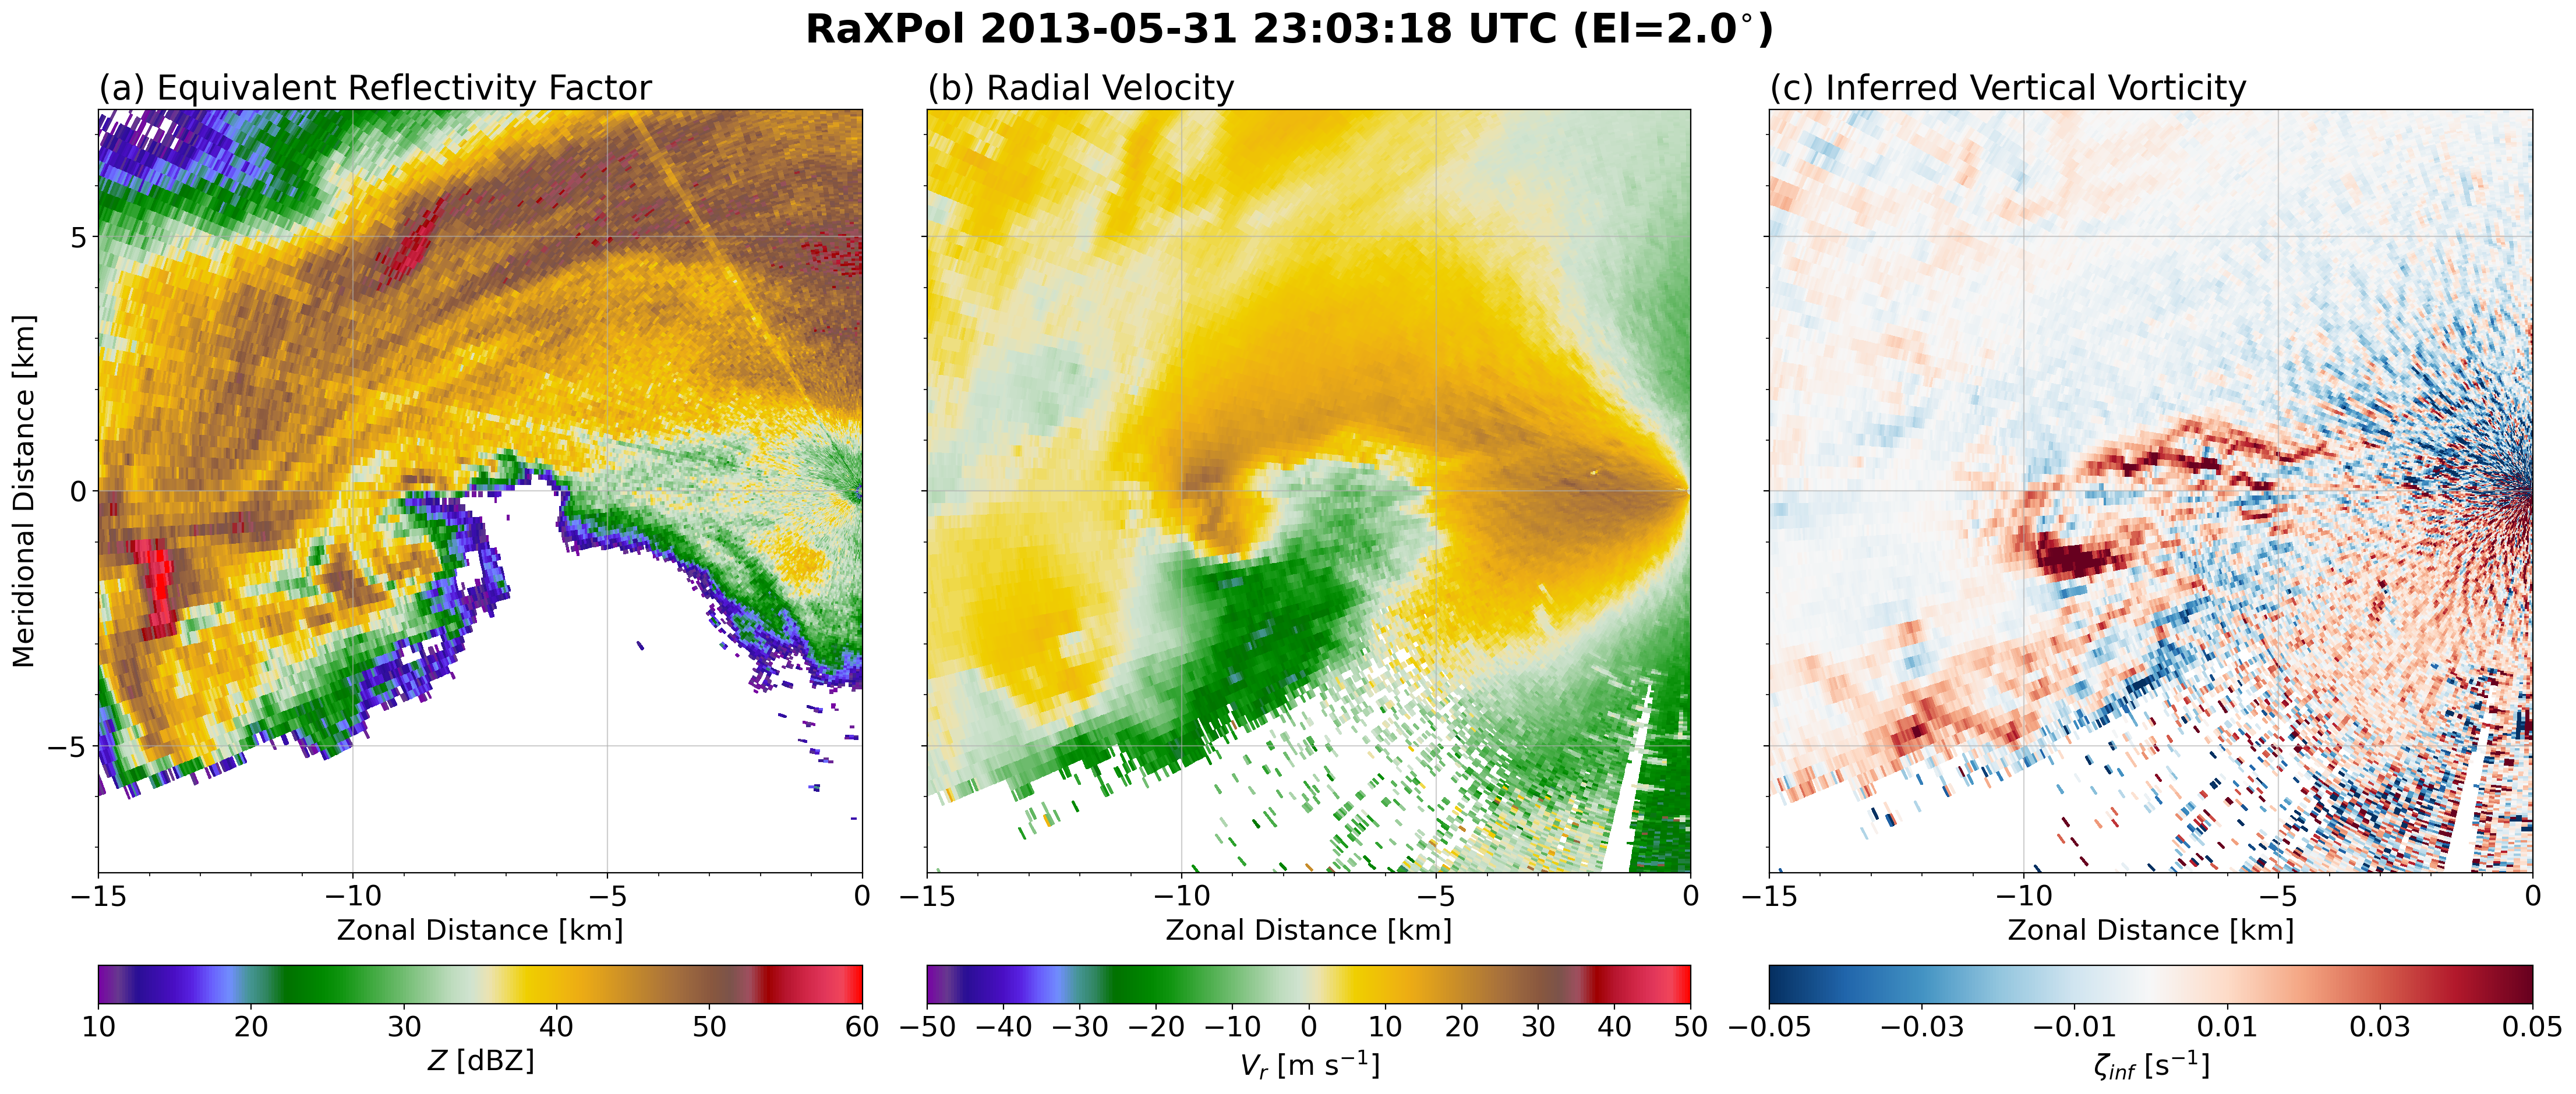

In [7]:
xlims = [-15,0]
ylims = [-7.5,7.5]

fig, axs = plt.subplots(figsize=(22,9.25), 
                        ncols=3, 
                        sharey=True,
                        sharex=True,
                        constrained_layout=True,
                        dpi=200)

fig.suptitle(f"RaXPol {tdt} UTC (El={el:.1f}$^{{\\circ}}$)", 
            fontsize=25, 
            fontweight='bold')

# reflectivity
ax = axs[0]
ax.set_title("(a) Equivalent Reflectivity Factor", loc='left')
vmin, vmax = 10, 60
ref_plot = np.ma.masked_less(ref-20, 10)
pcm = ax.pcolormesh(
    x/1e3,
    y/1e3,
    ref_plot,
    vmin=vmin,
    vmax=vmax,
    cmap='Carbone42'
    )
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.02, label="$Z$ [dBZ]")
cbar.set_ticks(np.arange(vmin, vmax + 0.1, 10))
ax.set_ylabel("Meridional Distance [km]")
pcm.set_rasterized(True)
# radial velocity
ax = axs[1]
ax.set_title("(b) Radial Velocity", loc='left')
vmin, vmax = -50, 50
pcm = ax.pcolormesh(
    x/1e3,
    y/1e3,
    vel,
    vmin=vmin,
    vmax=vmax,
    cmap='Carbone42'
    )
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.02, label="$V_r$ [m s$^{-1}$]")
cbar.set_ticks(np.arange(vmin, vmax + 0.1, 10))
pcm.set_rasterized(True)
# inferred vertical vorticity
ax = axs[2]
ax.set_title("(c) Inferred Vertical Vorticity", loc='left')
vmin, vmax = -0.05, 0.05
pcm = ax.pcolormesh(
    x/1e3, 
    y/1e3, 
    vort,
    vmin=vmin, 
    vmax=vmax,
    cmap='RdBu_r'
    )
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.02, label="$\zeta_{inf}$ [s$^{-1}$]")
cbar.set_ticks(np.arange(vmin, vmax+1e-10, 0.02))
pcm.set_rasterized(True)

# clean up plot
for iax in axs.flatten():
    iax.set_aspect('equal')
    iax.set_xlim(xlims)
    iax.xaxis.set_major_locator(MultipleLocator(5))
    iax.xaxis.set_minor_locator(MultipleLocator(1))
    iax.set_xlabel("Zonal Distance [km]")
    iax.set_ylim(ylims)
    iax.yaxis.set_major_locator(MultipleLocator(5))
    iax.yaxis.set_minor_locator(MultipleLocator(1))
    iax.grid(alpha=0.6)

# output
# dout = f"/home/robbyfrost/Figures/ouprime/20130531_225957_z_vel_zeta.pdf"
# plt.savefig(dout, dpi=200, bbox_inches='tight', format='pdf')
# print(f"Saved to: {dout}")

plt.show()
plt.close(fig)